<a href="https://colab.research.google.com/github/SandhuruT/Data_Science_01/blob/main/Data_Science_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


student_per = pd.read_csv("/content/student_performance.csv")
student_per.head()

,student_id,age,gender,study_hours_per_day,attendance_pct,parent_education,internet_access,extracurricular,sleep_hours,tuition,previous_grade,stress_level,final_grade,passed
0,S001,16,Male,6,92,Graduate,Yes,Yes,7,Yes,78,Medium,85,Yes
1,S002,17,Female,3,75,High School,No,No,6,No,55,High,58,No
2,S003,15,Male,7,95,Post Graduate,Yes,Yes,8,Yes,88,Low,91,Yes
3,S004,18,Female,2,60,High School,No,No,5,No,45,High,42,No
4,S005,16,Male,5,85,Graduate,Yes,No,7,Yes,72,Medium,76,Yes


In [46]:
student_per.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   student_id           150 non-null    object
 1   age                  150 non-null    int64 
 2   gender               150 non-null    object
 3   study_hours_per_day  150 non-null    int64 
 4   attendance_pct       150 non-null    int64 
 5   parent_education     150 non-null    object
 6   internet_access      150 non-null    object
 7   extracurricular      150 non-null    object
 8   sleep_hours          150 non-null    int64 
 9   tuition              150 non-null    object
 10  previous_grade       150 non-null    int64 
 11  stress_level         150 non-null    object
 12  final_grade          150 non-null    int64 
 13  passed               150 non-null    object
dtypes: int64(6), object(8)
memory usage: 16.5+ KB


In [47]:
student_per.describe()

,age,study_hours_per_day,attendance_pct,sleep_hours,previous_grade,final_grade
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,16.500000,4.440000,72.066667,6.753333,56.473333,58.326667
std,1.115781,2.312731,18.819405,0.982646,21.444386,23.741193
min,15.000000,1.000000,32.000000,5.000000,15.000000,12.000000
25%,16.000000,2.000000,57.250000,6.000000,38.000000,37.000000
50%,16.500000,4.000000,76.000000,7.000000,57.000000,60.500000
75%,17.000000,6.000000,89.000000,7.000000,75.750000,79.750000
max,18.000000,8.000000,99.000000,9.000000,93.000000,96.000000


In [48]:
student_per.dtypes

,0
student_id,object
age,int64
gender,object
study_hours_per_day,int64
attendance_pct,int64
parent_education,object
internet_access,object
extracurricular,object
sleep_hours,int64
tuition,object


In [49]:
student_per.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
attendance_pct,0
parent_education,0
internet_access,0
extracurricular,0
sleep_hours,0
tuition,0


In [50]:
# What is the overall pass rate?
student_per["passed"].value_counts()

,count
passed,
Yes,94
No,56


In [51]:
student_per["passed"] = (student_per["passed"] == "Yes").astype(int)

In [52]:
student_pass_rate = student_per['passed'].mean() * 100
print(f"Overall student_passr rate: {student_pass_rate:.2f}%")

Overall student_passr rate: 62.67%


In [53]:
student_per.dtypes

,0
student_id,object
age,int64
gender,object
study_hours_per_day,int64
attendance_pct,int64
parent_education,object
internet_access,object
extracurricular,object
sleep_hours,int64
tuition,object


In [54]:
stress_map = {'Low': 1, 'Medium': 2, 'High': 3}
student_per["stress_level"] = student_per["stress_level"].map(stress_map)

print(student_per.dtypes)
print(student_per[["stress_level","passed"]].head())

student_id             object
age                     int64
gender                 object
study_hours_per_day     int64
attendance_pct          int64
parent_education       object
internet_access        object
extracurricular        object
sleep_hours             int64
tuition                object
previous_grade          int64
stress_level            int64
final_grade             int64
passed                  int64
dtype: object
   stress_level  passed
0             2       1
1             3       0
2             1       1
3             3       0
4             2       1


In [55]:
student_per[["stress_level",'passed']].sum()

,0
stress_level,300
passed,94


In [56]:
student_per["stress_level"].unique()

array([2, 3, 1])

In [57]:
# Which factor has the biggest impact on passing?
student_per.groupby("passed")["study_hours_per_day"].mean()

,study_hours_per_day
passed,
0,1.946429
1,5.925532


In [58]:
student_per.groupby("passed")["attendance_pct"].mean()

,attendance_pct
passed,
0,51.589286
1,84.265957


In [59]:
student_per.groupby("passed")["sleep_hours"].mean()

,sleep_hours
passed,
0,5.660714
1,7.404255


In [60]:
# Does internet access affect final grade?
student_per.groupby("internet_access")["final_grade"].mean()

,final_grade
internet_access,
No,32.321429
Yes,73.819149


Text(0.5, 1.0, 'Distribution of Final Grades')

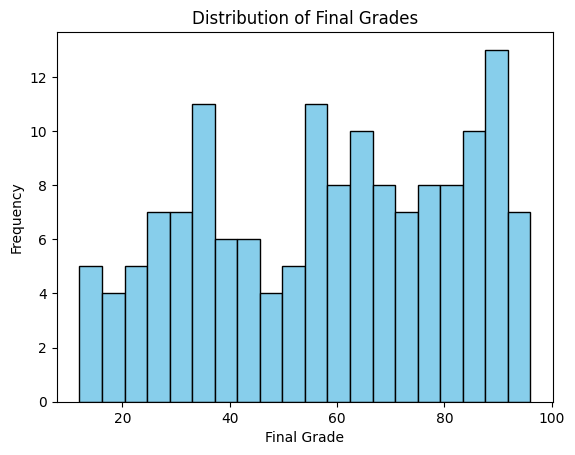

In [61]:
# Plot final grade distribution using a histogram.
plt.hist(student_per["final_grade"], bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.title("Distribution of Final Grades")

In [62]:
# Top 3 factors that differ most between passed and failed.
student_per.groupby("passed").mean(numeric_only=True).T

passed,0,1
age,16.678571,16.393617
study_hours_per_day,1.946429,5.925532
attendance_pct,51.589286,84.265957
sleep_hours,5.660714,7.404255
previous_grade,33.607143,70.095745
stress_level,3.000000,1.404255
final_grade,32.321429,73.819149


In [63]:
student_per.head()

,student_id,age,gender,study_hours_per_day,attendance_pct,parent_education,internet_access,extracurricular,sleep_hours,tuition,previous_grade,stress_level,final_grade,passed
0,S001,16,Male,6,92,Graduate,Yes,Yes,7,Yes,78,2,85,1
1,S002,17,Female,3,75,High School,No,No,6,No,55,3,58,0
2,S003,15,Male,7,95,Post Graduate,Yes,Yes,8,Yes,88,1,91,1
3,S004,18,Female,2,60,High School,No,No,5,No,45,3,42,0
4,S005,16,Male,5,85,Graduate,Yes,No,7,Yes,72,2,76,1


In [64]:
# Machine Learning (Feature Engineering)
Feature = ['age', 'study_hours_per_day', 'attendance_pct', 'sleep_hours', 'stress_level', 'previous_grade']

In [65]:
X = student_per[Feature].copy()
Y = student_per["passed"]

In [66]:
# Trsin / Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [67]:
print(f"training rows: {len(X_train)}")
print(f"training rows: {len(X_test)}")

training rows: 120
training rows: 30


In [68]:
model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train,Y_train)

print("Model trained succssfully")
print(f"Number of leaves: {model.get_n_leaves()}")  # number of path through the trees
print(f"Tree depth: {model.get_depth()}")   # number of question asked

Model trained succssfully
Number of leaves: 2
Tree depth: 1


In [69]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test,y_pred) *100:2f}%")
print("Classification Report:")
print(classification_report(Y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test,y_pred))

Accuracy: 100.000000%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        21

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[ 9  0]
 [ 0 21]]


In [72]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
scores = cross_val_score(rf_cv, X, Y, cv=5, scoring='accuracy')

print(f"CV scores: {scores.round(2)}")
print(f"Average: {scores.mean():.2f}")
print(f"Std dev: {scores.std():.2f}")

CV scores: [1. 1. 1. 1. 1.]
Average: 1.00
Std dev: 0.00
